# Assignment 1 - 46770 Integrated Energy Grids  
February 2026

In this first part of the course project, you are asked to carry out the tasks described below.

Write a short report (maximum length 6 pages) in groups of 4 students, including your main findings, and upload it to DTULearn.

Deadline for submission: March 25, 2026, 23:55


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import pypsa

## Adding the data and cleaning
**Getting the Data Paths**

In [2]:
BASE_DIR = Path.cwd()  
DATA_DIR = BASE_DIR.parent / "data"
PLOTS_DIR = BASE_DIR.parent / "Plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

GENERATION_FILE = DATA_DIR / "energy-charts_Public_net_electricity_generation_in_Germany_in_2024_renewablesgene.csv"
LOAD_FILE = DATA_DIR / "energy-charts_Public_net_electricity_generation_in_Germany_in_2024_load.csv"

**Read files + fixing column names**

In [3]:
print("Reading files...")
print("Generation file:", GENERATION_FILE)
print("Load file:", LOAD_FILE)

# Extracting the raw column names to understand the structure of the data
gen_raw = pd.read_csv(GENERATION_FILE)
load_raw = pd.read_csv(LOAD_FILE)

# Getting the column names and stripping (taking out) any leading/trailing whitespaces
gen_raw.columns = [str(c).strip() for c in gen_raw.columns]
load_raw.columns = [str(c).strip() for c in load_raw.columns]

print("\nGeneration columns:")
print(gen_raw.columns.tolist())

print("\nLoad columns:")
print(load_raw.columns.tolist())

# _____________________________________________________________________
# Fixing column names
GENERATION_TIME_COL = gen_raw.columns[0]
LOAD_TIME_COL = load_raw.columns[0]

# generation file expected columns
WIND_OFFSHORE_COL = "Wind offshore"
WIND_ONSHORE_COL = "Wind onshore"
SOLAR_COL = "Solar"  # IMPORTANT!: The historical solar generation data used in the model is aggregated and does not distinguish between rooftop and utility-scale PV.

# load file expected column
LOAD_COL = "Load"

Reading files...
Generation file: c:\Users\Fernando\OneDrive - Danmarks Tekniske Universitet\Escritorio\MscSustainableEnergy\4 Semester\46770 Integrated Energy Grids\Assignment\Integrated_Energy_Grids\data\energy-charts_Public_net_electricity_generation_in_Germany_in_2024_renewablesgene.csv
Load file: c:\Users\Fernando\OneDrive - Danmarks Tekniske Universitet\Escritorio\MscSustainableEnergy\4 Semester\46770 Integrated Energy Grids\Assignment\Integrated_Energy_Grids\data\energy-charts_Public_net_electricity_generation_in_Germany_in_2024_load.csv

Generation columns:
['Date (GMT+1)', 'Wind offshore', 'Wind onshore', 'Solar']

Load columns:
['Date (GMT+1)', 'Load']


**Parsing dates**

In [4]:
def parse_time(series):
    # Turn data col into date time format
    try:
        return pd.to_datetime(series, errors="coerce", utc=True, format="mixed")
    except Exception:
        return pd.to_datetime(series, errors="coerce", utc=True)

gen_raw[GENERATION_TIME_COL] = parse_time(gen_raw[GENERATION_TIME_COL])
load_raw[LOAD_TIME_COL] = parse_time(load_raw[LOAD_TIME_COL])

gen_raw = gen_raw.dropna(subset=[GENERATION_TIME_COL]).copy()
load_raw = load_raw.dropna(subset=[LOAD_TIME_COL]).copy()

gen_raw = gen_raw.set_index(GENERATION_TIME_COL)
load_raw = load_raw.set_index(LOAD_TIME_COL)

# If the time index of both load and generation files has timezone info, we:
# - Try to convert it to "Europe/Berlin" timezone and 
# - then remove the timezone info (localize to None)
# With this we achieve a clean UTC(Universal Time Coordinated) time index without timezone info, which is easier to work with.
if getattr(gen_raw.index, "tz", None) is not None:
    gen_raw.index = gen_raw.index.tz_convert("UTC").tz_localize(None)
    gen_raw.index.name = "Date"

if getattr(load_raw.index, "tz", None) is not None:
    load_raw.index = load_raw.index.tz_convert("UTC").tz_localize(None)
    load_raw.index.name = "Date"

**Data cleaning**

In [5]:
def parse_number(series):
    # Turn data col into numeric format, removing any non-numeric characters (like spaces, commas, etc.)
    s = series.astype(str).str.strip()
    s = s.str.replace("\u202f", "", regex=False)
    s = s.str.replace("\xa0", "", regex=False)
    s = s.str.replace(" ", "", regex=False)
    s = s.str.replace(",", "", regex=False)
    return pd.to_numeric(s, errors="coerce")

gen = pd.DataFrame(index=gen_raw.index)
gen["wind_offshore"] = parse_number(gen_raw[WIND_OFFSHORE_COL])
gen["wind_onshore"] = parse_number(gen_raw[WIND_ONSHORE_COL])
gen["solar"] = parse_number(gen_raw[SOLAR_COL])

load = pd.DataFrame(index=load_raw.index)
load["load"] = parse_number(load_raw[LOAD_COL])

# Join generation and load dataframes on their time index, keeping only the rows where both have data (inner join)
df = gen.join(load, how="inner")
df = df.dropna().copy()
df = df.groupby(df.index).mean()
df = df[(df.index >= "2024-01-01") & (df.index < "2025-01-01")].copy()

# Convert 15-minute data to hourly averages
df = df.resample("1h").mean()

print("\nFirst rows:")
print(df.head())

print("\nShape:")
print(df.shape)


First rows:
                     wind_offshore  wind_onshore  solar       load
Date                                                              
2024-01-01 00:00:00       5348.775     29017.375  0.000  38818.125
2024-01-01 01:00:00       5191.500     29096.325  0.000  37847.550
2024-01-01 02:00:00       4676.750     28569.225  0.000  37123.225
2024-01-01 03:00:00       4441.875     28502.700  1.325  36753.525
2024-01-01 04:00:00       4627.325     28627.275  2.950  37051.400

Shape:
(8783, 4)


## Part A
Choose one country/region/city/system and calculate the optimal capacities for renewable and non-renewable generators. You can add as many technologies as you want. Remember to provide a reference for the costs and other technological assumptions. Plot the dispatch time series for a week in summer and winter. Plot the annual electricity mix. Use the duration curves or the capacity factor to investigate the contribution of different technologies.


### Technology 
#### Capacity factors

In [6]:
# Data taken from: 
# https://energy-charts.info/charts/installed_power/chart.htm?l=en&c=DE&year=2024

WIND_ONSHORE_CAPACITY_MW    = 63590
WIND_OFFSHORE_CAPACITY_MW   = 9220
SOLAR_CAPACITY_MW           = 92410
GAS_INSTALLED_CAPACITY_MW   = 35600

wind_onshore_cf     = (df["wind_onshore"] / WIND_ONSHORE_CAPACITY_MW).clip(lower=0, upper=1)
wind_offshore_cf    = (df["wind_offshore"] / WIND_OFFSHORE_CAPACITY_MW).clip(lower=0, upper=1)
solar_cf            = (df["solar"] / SOLAR_CAPACITY_MW).clip(lower=0, upper=1)
demand_series       = df["load"].clip(lower=0)

print("Onshore wind mean capacity factor:", wind_onshore_cf.mean())
print("Offshore wind mean capacity factor:", wind_offshore_cf.mean())
print("Utility solar mean capacity factor:", solar_cf.mean())
#.clip(lower, uppper) are basically used to ensure that any data point is not negative or goes beyond 1, 
# which is important for capacity factors and demand.

Onshore wind mean capacity factor: 0.19804963065452413
Offshore wind mean capacity factor: 0.3170727794993434
Utility solar mean capacity factor: 0.0735635621196337


#### Cost assumptions
SOURCE: https://www.sciencedirect.com/science/article/pii/S0196890419309835 


Found the co2 price here, I saw for CCGT it ranges fro 90$/tCO2 to 103$/tCO2, I took a value in the middle and turned it into euros 96.5$ = 84.15 €
https://publications.ieaghg.org/technicalreports/2024-03%20Techno-Economic%20Assessment%20of%20Small-Scale%20Carbon%20Capture%20for%20Industrial%20and%20Power%20Systems.pdf

In [7]:
def annuity(n, r):
    # Annuity is basically a way to calculate the equivalent annual cost of an investment, taking into account the time value of money.
    """Annuity factor for lifetime n years and discount rate r."""
    if r > 0:
        return r / (1.0 - 1.0 / (1.0 + r) ** n)
    else:
        return 1.0 / n

In [8]:
discount_rate = 0.07

# Onshore wind
lifetime_ONW = 30  # years
ONW_CAPEX_MW = 910000 # EUR/MW
fixed_OM_onshorewind = 0.033
capital_cost_onshorewind = annuity(lifetime_ONW, discount_rate) * ONW_CAPEX_MW * (1 + fixed_OM_onshorewind)   # EUR/MW-year
marginal_cost_onshorewind = 0

# Offshore wind
lifetime_OFW = 25  # years
OFW_CAPEX_MW = 2506000 # EUR/MW
fixed_OM_offshorewind = 0.03
capital_cost_offshorewind = annuity(lifetime_OFW, discount_rate) * OFW_CAPEX_MW * (1 + fixed_OM_offshorewind)   # EUR/MW-year
marginal_cost_offshorewind = 0

# Solar PV - UTILITY SCALE
lifetime_PV = 25  # years
PV_CAPEX_MW = 425000 # EUR/MW - Utility scale figures
fixed_OM_solar = 0.03
capital_cost_solar = annuity(lifetime_PV, discount_rate) * PV_CAPEX_MW * (1 + fixed_OM_solar)           # EUR/MW-year
marginal_cost_solar = 0

# Gas (as OCGT, Open Cycle Gas Turbine)
# In our data source for the amount of gas installed in DEU it is not specified if its CCGT or OCGT
# but since the paper found has OCGT numbers, we will assume it is OCGT, which has a shorter lifetime and higher fuel costs than CCGT.
lifetime_GAS = 25  # years
GAS_CAPEX_MW = 560000 # EUR/MW
fixed_OM_gas = 0.033
capital_cost_gas = annuity(lifetime_GAS, discount_rate) * GAS_CAPEX_MW * (1 + fixed_OM_gas) # EUR/MW-year
fuel_cost_gas = 21.6                                      # EUR/MWh_th
efficiency_gas = 0.39
emission_factor_gas = 0.19                                # tCO2/MWh_th
co2_intensity_gas = emission_factor_gas / efficiency_gas  # tCO2/MWh_el
co2_price = 84.15                                         # €/tCO2 
marginal_cost_gas = fuel_cost_gas / efficiency_gas + co2_price * co2_intensity_gas   # EUR/MWh_el

### Network build

In [9]:
n = pypsa.Network()
n.set_snapshots(df.index)

# ___ CARRIERS ___
n.add("Carrier", "electricity")
n.add("Carrier", "wind_onshore")
n.add("Carrier", "wind_offshore")
n.add("Carrier", "solar")
n.add("Carrier", "gas")

# ___ BUSES ___
n.add("Bus", "electricity", carrier="electricity")

# ___ LOADS ___
n.add("Load", "demand", bus="electricity", p_set=demand_series)

# ___ GENERATORS ___
n.add(
    "Generator",
    "wind_onshore",
    bus="electricity",
    carrier="wind_onshore",
    p_nom_extendable=True,
    capital_cost=capital_cost_onshorewind,
    marginal_cost=marginal_cost_onshorewind,
    p_max_pu=wind_onshore_cf
)

n.add(
    "Generator",
    "wind_offshore",
    bus="electricity",
    carrier="wind_offshore",
    p_nom_extendable=True,
    capital_cost=capital_cost_offshorewind,
    marginal_cost=marginal_cost_offshorewind,
    p_max_pu=wind_offshore_cf
)

n.add(
    "Generator",
    "solar",
    bus="electricity",
    carrier="solar",
    p_nom_extendable=True,
    capital_cost=capital_cost_solar,
    marginal_cost=marginal_cost_solar,
    p_max_pu=solar_cf
)

n.add(
    "Generator",
    "gas",
    bus="electricity",
    carrier="gas",
    p_nom_extendable=True,
    capital_cost=capital_cost_gas,
    marginal_cost=marginal_cost_gas,
    p_max_pu=1.0    # Alwayas available
)


n.buses.index       = n.buses.index.astype(object)
n.loads.index       = n.loads.index.astype(object)
n.generators.index  = n.generators.index.astype(object)
n.loads["bus"]      = n.loads["bus"].astype(object)
n.generators["bus"] = n.generators["bus"].astype(object)

**Optimize**

In [10]:
print("\nRunning Optimization...")
n.optimize(solver_name="highs")


Running Optimization...


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 189.07it/s]
INFO:linopy.io: Writing time: 0.2s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 35136 primals, 79051 duals
Objective: 3.48e+10
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


('ok', 'optimal')

In [11]:
print("\nOptimal capacities (MW):")
print(n.generators.p_nom_opt)


Optimal capacities (MW):
name
wind_onshore     167827.675490
wind_offshore        -0.000000
solar            114795.986126
gas               66771.679528
Name: p_nom_opt, dtype: float64


### Plots

#### Summer Dispatch

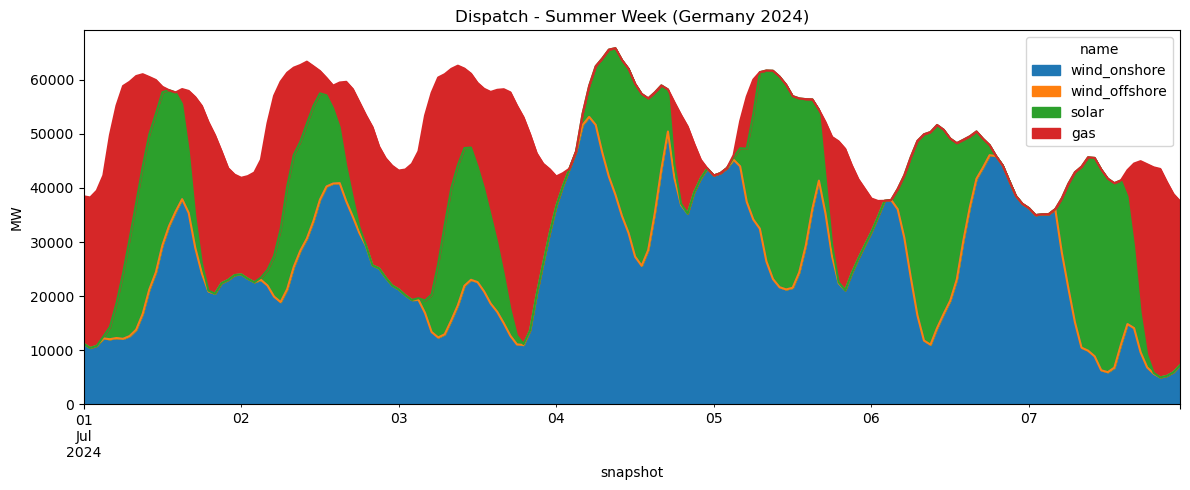


Saved figure in Plots folder.


In [12]:
summer = n.generators_t.p.loc["2024-07-01":"2024-07-07"]
summer.plot.area(figsize=(12, 5))
plt.title("Dispatch - Summer Week (Germany 2024)")
plt.ylabel("MW")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "summer_dispatch.png", dpi=200)
plt.show()
plt.close()

print("\nSaved figure in Plots folder.")

#### Winter Dispatch

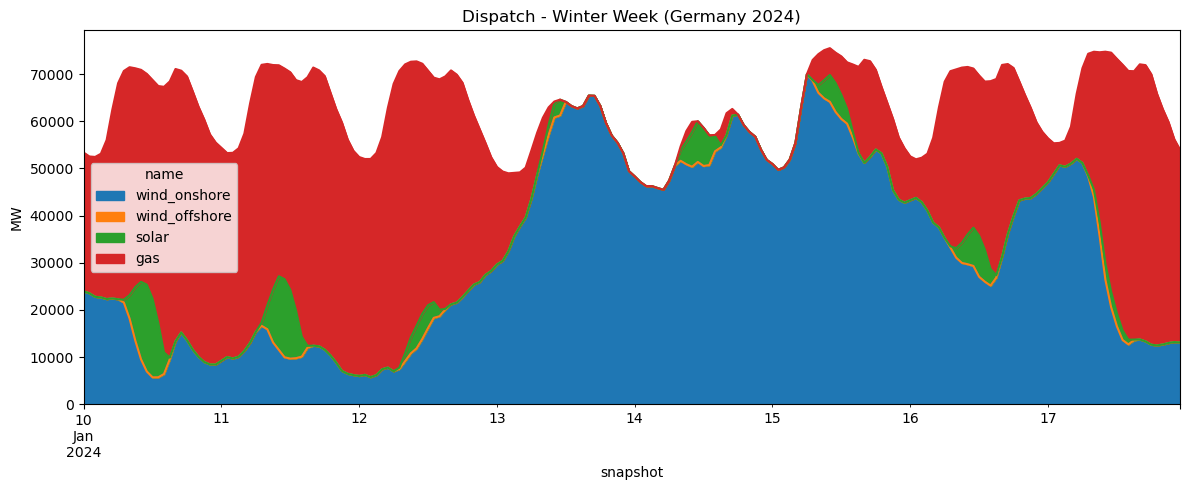


Saved figure in Plots folder.


In [13]:
winter = n.generators_t.p.loc["2024-01-10":"2024-01-17"]
winter.plot.area(figsize=(12, 5))
plt.title("Dispatch - Winter Week (Germany 2024)")
plt.ylabel("MW")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "winter_dispatch.png", dpi=200)
plt.show()
plt.close()

print("\nSaved figure in Plots folder.")

#### Annual Mix

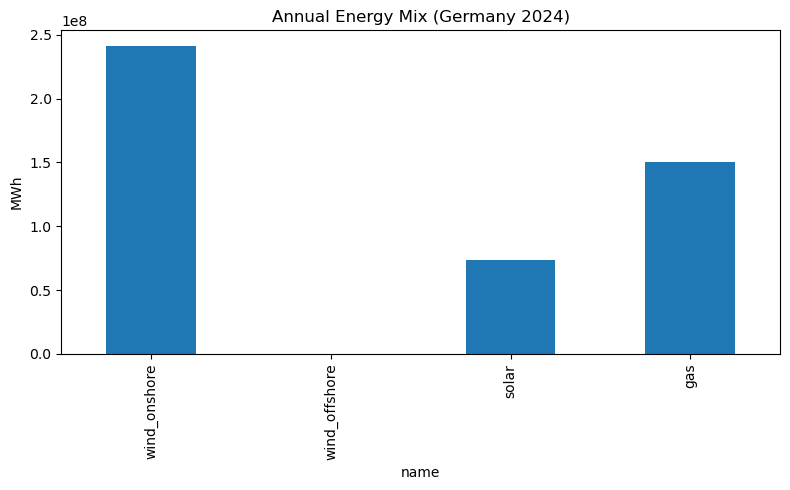


Saved figure in Plots folder.

Annual energy production (MWh):
name
wind_onshore     2.414644e+08
wind_offshore    0.000000e+00
solar            7.352147e+07
gas              1.504768e+08
dtype: float64

Capacity factors:
name
wind_onshore     0.163812
wind_offshore         NaN
solar            0.072920
gas              0.256587
dtype: float64


In [14]:
annual_mix = n.generators_t.p.sum()
annual_mix.plot(kind="bar", figsize=(8, 5))
plt.title("Annual Energy Mix (Germany 2024)")
plt.ylabel("MWh")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "annual_mix.png", dpi=200)
plt.show()
plt.close()

print("\nSaved figure in Plots folder.")

print("\nAnnual energy production (MWh):")
print(annual_mix)

capacity_factor = n.generators_t.p.sum() / (n.generators.p_nom_opt * len(n.snapshots))

print("\nCapacity factors:")
print(capacity_factor)

#### Duration Curves

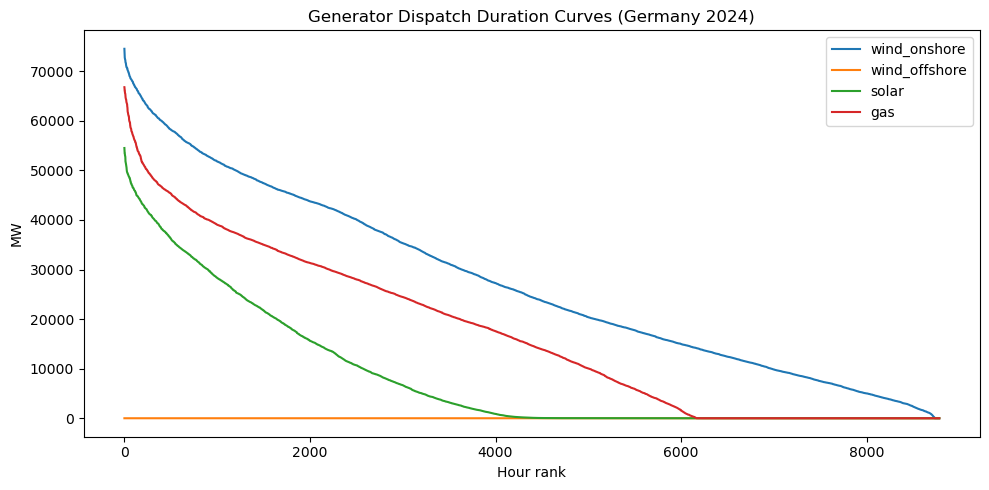


Saved figure in Plots folder.


In [15]:
plt.figure(figsize=(10, 5))
for gen_name in n.generators.index:
    sorted_dispatch = n.generators_t.p[gen_name].sort_values(ascending=False).reset_index(drop=True)
    plt.plot(sorted_dispatch, label=gen_name)

plt.title("Generator Dispatch Duration Curves (Germany 2024)")
plt.xlabel("Hour rank")
plt.ylabel("MW")
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "duration_curves.png", dpi=200)
plt.show()
plt.close()

print("\nSaved figure in Plots folder.")

# Section B
Investigate how sensitive your results are to the interannual variability of solar and wind generation. Plot the average capacity and variability obtained for every generator using different weather years.


In [16]:
weather_years = [...]  # e.g. [2013, 2014, 2015, 2016]

# For each weather year:
# 1) build the same model as (a)
# 2) use that year's wind/solar profiles
# 3) optimise and store p_nom_opt
#
# capacities = []
# for y in weather_years:
#     n = ...  # build network for year y
#     n.optimize(solver_name=SOLVER_NAME)
#     capacities.append(n.generators.p_nom_opt.rename(y))
#
# cap = pd.concat(capacities, axis=1).T  # rows=years, cols=generators
# cap_mean = cap.mean(axis=0)
# cap_std = cap.std(axis=0)
#
# ax = cap_mean.sort_values(ascending=False).plot(kind="bar", yerr=cap_std[cap_mean.sort_values(ascending=False).index], figsize=(10, 3))
# ax.set_title("Optimal capacities across weather years (mean ± std)")


## c)
Add some storage technology/ies and investigate how they behave and what their impact is on the optimal system configuration. Discuss what strategies your system is using to balance the renewable generation at different time scales (intraday, seasonal, etc.)


In [17]:
# Starting from your best model in (a)/(b): add storage and re-optimise

# Example (StorageUnit):
# n.add(
#     "StorageUnit",
#     "battery",
#     bus=region,
#     p_nom_extendable=True,
#     max_hours=4,
#     capital_cost=...,  # reference in report
#     marginal_cost=0.0,
#     efficiency_store=0.95,
#     efficiency_dispatch=0.95,
# )
#
# n.optimize(solver_name=SOLVER_NAME)
#
# n.storage_units_t.p.plot(figsize=(10, 3)); plt.title("Storage dispatch")
# n.storage_units_t.state_of_charge.plot(figsize=(10, 3)); plt.title("State of charge")


## d)
Connect your country to at least three neighbouring countries using HVAC lines, making sure that the network includes at least one closed cycle. Look for information on the existing capacities of those interconnectors and set the capacities fixed. Assume a voltage level of 400 kV and a unitary reactance x=0.1. You can assume that the generation capacities in the neighbouring countries are fixed or co-optimise the whole system. Optimise the whole system, assuming linearised AC power flow (DC approximation) and discuss the results.


In [18]:
# Build a multi-area network with at least 4 buses (home + 3 neighbours)
# Ensure at least one cycle in the line topology

# areas = ["<HOME>", "<N1>", "<N2>", "<N3>"]
# n = pypsa.Network()
# n.set_snapshots(snapshots)
# for a in areas:
#     n.add("Bus", a)
#     n.add("Load", f"load_{a}", bus=a, p_set=...)
#     # add generators in each area (fixed or extendable)
#
# interconnectors = {
#     # ("<HOME>", "<N1>"): {"s_nom": ...},
#     # ("<N1>", "<N2>"): {"s_nom": ...},
#     # ("<N2>", "<HOME>"): {"s_nom": ...},  # closes a cycle
#     # ("<HOME>", "<N3>"): {"s_nom": ...},
# }
# for (b0, b1), p in interconnectors.items():
#     n.add(
#         "Line",
#         f"{b0}-{b1}",
#         bus0=b0,
#         bus1=b1,
#         s_nom=p["s_nom"],
#         x=0.1,
#         v_nom=400.0,
#     )
#
# n.optimize(solver_name=SOLVER_NAME)


## e)
(Note: this section must be solved with pen and paper. The objective is to replicate the power flows that you obtained for the first time step in your simulation.)

Calculate the incidence matrix and the power transfer distribution factor (PTDF) matrix of the network that you defined in the previous section. Read from your PyPSA model the imbalances in the first time step in every node (i.e. generation - demand). Assuming linearised AC power flows, and the previously determined PTDF matrix, calculate the optimal power flowing through every line and check that it coincides with the modelled results.


In [19]:
# Helper outputs for the pen-and-paper PTDF calculation (after you solved part d)

# t0 = n.snapshots[0]
#
# gen_t0 = n.generators_t.p.loc[t0]
# load_t0 = n.loads_t.p.loc[t0]
#
# injections = gen_t0.groupby(n.generators.bus).sum().reindex(n.buses.index).fillna(0.0)
# withdrawals = load_t0.groupby(n.loads.bus).sum().reindex(n.buses.index).fillna(0.0)
# imbalance = injections - withdrawals
#
# lines = n.lines[["bus0", "bus1", "x", "s_nom"]].copy()
# flows_t0 = n.lines_t.p0.loc[t0]  # flow from bus0 -> bus1
#
# imbalance, lines, flows_t0
